In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [40]:
img = cv2.imread('Lenna.png', cv2.IMREAD_GRAYSCALE)
print(img.shape)

(512, 512)


## 1.影像平移(套件&手做)

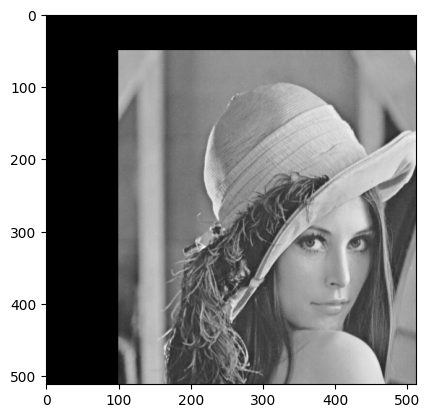

In [41]:
h, w = img.shape[:2]
M_translate = np.float32([[1, 0, 100], [0, 1, 50]])  # x 移動 100, y 移動 50
translated_1 = cv2.warpAffine(img, M_translate, (w, h))
plt.imshow(translated_1, cmap='gray')

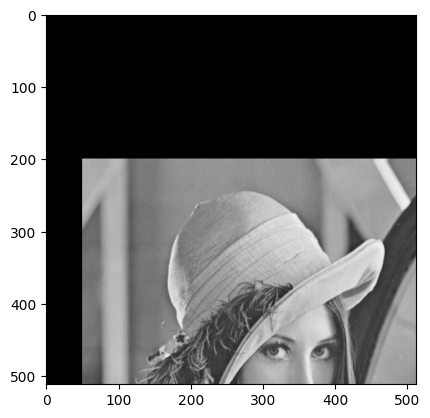

In [42]:
dy, dx = 100, 50
translated_2 = np.zeros_like(img)
for y in range(h):
  for x in range(w):
    new_y = y + 200
    new_x = x + 50

    if new_y < h and new_x < w:
      translated_2[new_y, new_x] = img[y, x]
plt.imshow(translated_2, cmap='gray')

## 2.影像縮放

Text(0.5, 1.0, 'scaled 0.5')

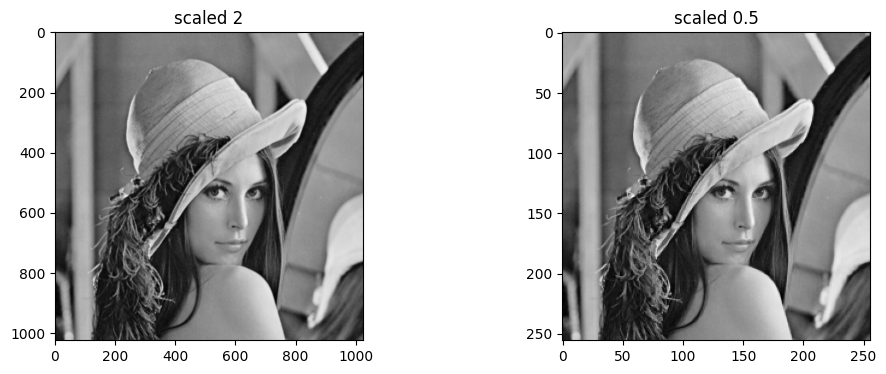

In [43]:
scaled_2 = cv2.resize(img, (w*2, h*2))
scaled_0_5 = cv2.resize(img, (w//2, h//2))
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.imshow(scaled_2, cmap='gray')
plt.title('scaled 2')
plt.subplot(1, 2, 2)
plt.imshow(scaled_0_5, cmap='gray')
plt.title('scaled 0.5')

## 3.影像旋轉

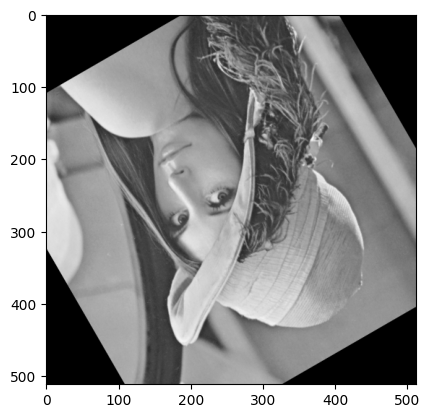

In [44]:
def rotation_matrix(degree, cx, cy):
  theta = np.radians(degree)  # 角度轉弧度
  cos_t = np.cos(theta)
  sin_t = np.sin(theta)
  R = np.array([[cos_t, -sin_t, (1-cos_t)*cx + sin_t*cy], #平移部分是為了找中心點，之後帶入w//2 h//2
          [sin_t, cos_t, (1-cos_t)*cy - sin_t*cx]])
  return R
degree = 150
M = rotation_matrix(degree, w/2, h/2)
rotated = cv2.warpAffine(img, M, (w, h))
plt.imshow(rotated, cmap='gray')

## 4.影像鏡射

Text(0.5, 1.0, '180 flip')

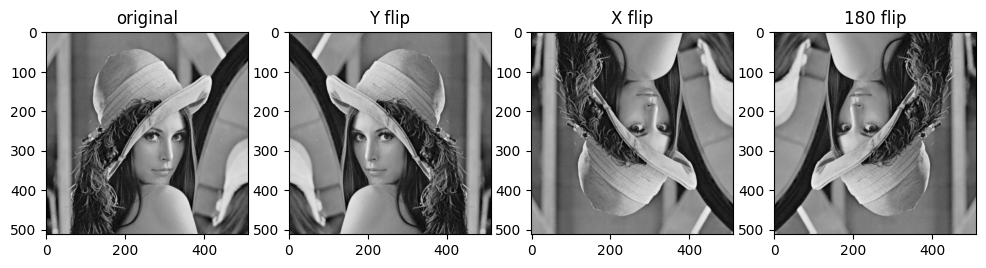

In [45]:
h, w = img.shape[:2]

# 水平
flip_h = np.zeros_like(img)
for y in range(h):
  for x in range(w):
    flip_h[y, x] = img[y, w-x-1]

# 垂直
flip_w = np.zeros_like(img)
for y in range(h):
  for x in range(w):
    flip_w[y, x] = img[h-y-1, x]

# 180度
flip_180 = np.zeros_like(img)
for y in range(h):
  for x in range(w):
    flip_180[y, x] = img[h-y-1, w-x-1]

plt.figure(figsize=(12, 4))
plt.subplot(1, 4, 1)
plt.title('original')
plt.imshow(img, cmap='gray')
plt.subplot(1, 4, 2)
plt.title('Y flip')
plt.imshow(flip_h, cmap='gray')
plt.subplot(1, 4, 3)
plt.title('X flip')
plt.imshow(flip_w, cmap='gray')
plt.subplot(1, 4, 4)
plt.imshow(flip_180, cmap='gray')
plt.title('180 flip')

## 補充：合成轉移矩陣 (線性代數複習)

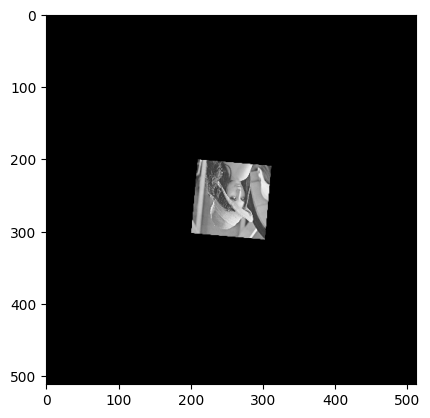

In [46]:
img = cv2.imread('Lenna.png', cv2.IMREAD_GRAYSCALE)
h, w = img.shape[:2]
theta = np.deg2rad(175)
scale_y, scale_x = 0.2, 0.2

to_orin = np.array([[1, 0, -(w//2)],
        [0, 1, -(h//2)],
        [0, 0, 1]] )

R = np.array([[np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]] )

back_orin = np.array([[1, 0, (w//2)],
        [0, 1, (h//2)],
        [0, 0, 1]] )

S = np.array([[scale_x, 0, 0],
        [0, scale_y, 0],
        [0, 0, 1]] )
F = np.array([[-1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]] )

M = back_orin @ F @ R @ S @ to_orin
M_affine = M[:2, :]
Combine_trans = cv2.warpAffine(img, M_affine, (w, h))
plt.imshow(Combine_trans, cmap='gray')

## 5.仿射變換

In [47]:
import numpy as np

ps1 = np.float32([[10, 20], [25, 10], [45, 48]])
ps2 = np.float32([[23, 20], [141, 10], [20, 65]])

A = []
B = []

#補充zip語法：
#(1, 2, 3) 和 (4, 5, 6)去zip後，會變成對應狀況
#1 4
#2 5
#3 6

#x = ax+by+t y = cx+dy+t'
#共要求解 : a, b, c, d, tx, ty
#[x₁  y₁  1  0   0  0]     [a]     [x'₁]
#[0   0  0  x₁  y₁  1]     [b]     [y'₁]
#[x₂  y₂  1  0   0  0]  ×  [tx]  =  [x'₂]
#[0   0  0  x₂  y₂  1]     [c]     [y'₂]
#[x₃  y₃  1  0   0  0]     [d]     [x'₃]
#[0   0  0  x₃  y₃  1]     [ty]     [y'₃]
for (x, y), (xp, yp) in zip(ps1, ps2):
  A.append([x, y, 1, 0, 0, 0])
  B.append(xp)

  A.append([0, 0, 0, x, y, 1])
  B.append(yp)


A = np.array(A, dtype=np.float32)  # (6,6)
B = np.array(B, dtype=np.float32)

# det(A)若等於0，代表此線性方程組無解
if np.linalg.det(A) == 0:
    print("這組點無法解出唯一的仿射矩陣")
else:
  M = np.linalg.solve(A, B).reshape(2, 3)

print(M)

[[ 4.251948   -5.422078   88.92208   ]
 [ 0.22077923  1.3311689  -8.831169  ]]


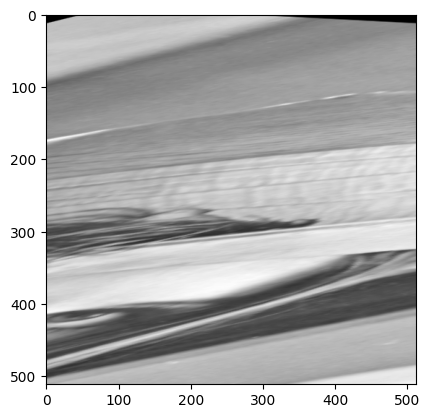

In [48]:
#套用算出的變換矩陣
affine_trans = cv2.warpAffine(img, M, (w, h))
plt.imshow(affine_trans, cmap='gray')